In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

candidates = [Path.cwd(), Path.cwd() / "datasets" / "round1"]
data_dir = next(path for path in candidates if (path / "trades_round_1_day_0.csv").exists())

trades = pd.read_csv(data_dir / "trades_round_1_day_0.csv", sep=";")
prices = pd.read_csv(data_dir / "prices_round_1_day_0.csv", sep=";")

In [ ]:
product = "ASH_COATED_OSMIUM"

ash_trades = trades.loc[trades["symbol"] == product].sort_values("timestamp").copy()
ash_prices = prices.loc[prices["product"] == product].sort_values("timestamp").copy()
bid_columns = [col for col in ash_prices.columns if col.startswith("bid_price_")]
ask_columns = [col for col in ash_prices.columns if col.startswith("ask_price_")]
ash_prices = ash_prices.dropna(subset=bid_columns, how="all").copy()
ash_prices = ash_prices.dropna(subset=ask_columns, how="all").copy()

ash_prices[["timestamp", "mid_price"]].head(), ash_trades[["timestamp", "price", "quantity"]].head()

(   timestamp  mid_price
 0          0    10013.0
 3        100    10003.0
 5        200    10003.5
 6        300    10002.0
 8        400    10002.0,
    timestamp    price  quantity
 3       6300  10009.0         5
 5       7000  10008.0         4
 6       7100  10008.0         3
 7       8600  10008.0         5
 8       9300   9992.0         7)

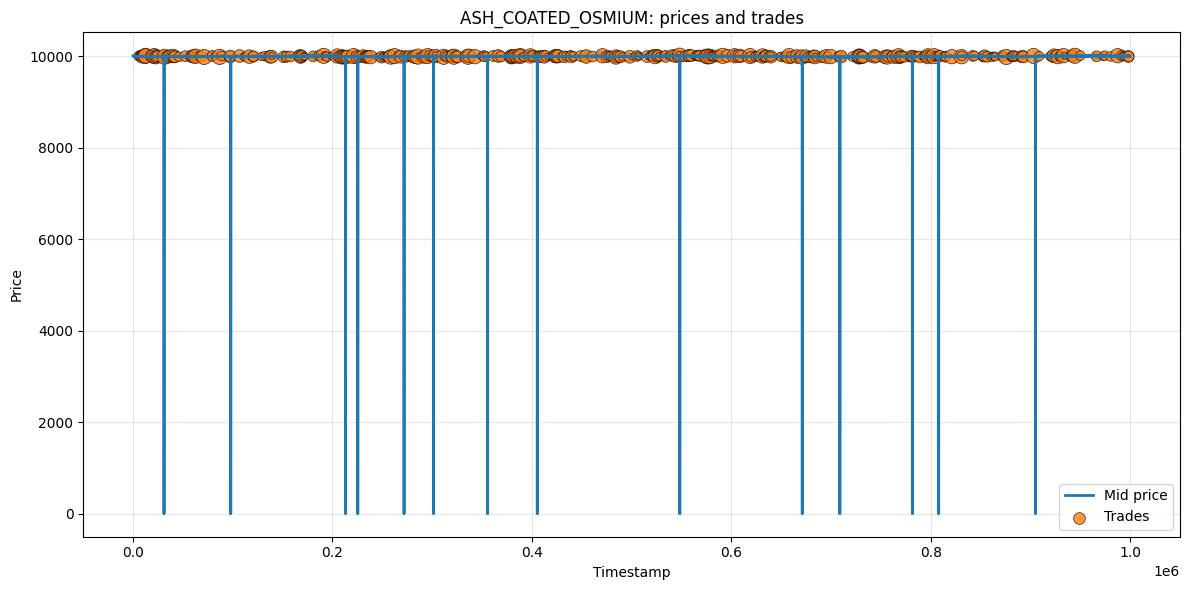

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    ash_prices["timestamp"],
    ash_prices["bid_price_1"],
    color="tab:green",
    linewidth=1.5,
    label="Best bid",
)

ax.plot(
    ash_prices["timestamp"],
    ash_prices["ask_price_1"],
    color="tab:red",
    linewidth=1.5,
    label="Best ask",
)

ax.plot(
    ash_prices["timestamp"],
    ash_prices["mid_price"],
    color="tab:blue",
    linewidth=2,
    label="Mid price",
)

ax.scatter(
    ash_trades["timestamp"],
    ash_trades["price"],
    s=ash_trades["quantity"] * 12,
    color="tab:orange",
    alpha=0.8,
    edgecolor="black",
    linewidth=0.5,
    label="Trades",
)

ax.set_title(f"{product}: bids, asks, mid price, and trades")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [24]:
ash_trades.head()

,timestamp,buyer,seller,symbol,currency,price,quantity
3,6300,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10009.0,5
5,7000,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10008.0,4
6,7100,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10008.0,3
7,8600,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10008.0,5
8,9300,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9992.0,7
